# 200 — TAR · bloque conjunto ξ₁..ξ₄ · E_04 evaluación

Predicción a h=1 sobre train y test, banda por cuantiles y las diez métricas sobre la ventana móvil contra la curva suavizada. Persiste `banda_funcional_psbp_mv.npz`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RAIZ = Path.cwd().resolve().parent
sys.path.insert(0, str(RAIZ))
from mv_psbp.pipeline import *
from mv_psbp import datos, convergencia, evaluacion, comparacion
pd.set_option("display.width", 200)


In [2]:
# [CONFIG]
ESC       = "200"           # escenario de la corrida viva (se lee de fuera, no se modifica)
EID       = "mvb_escenario_200_chungEscG_1_r01_K10"
EID_MV    = "mv_escenario_200_chungEscG_1_r01_K10"       # conjunto completo (K coordenadas), tercer competidor en E_05
DOMINIO   = "simulaciones"
BLOQUE    = (0, 1, 2, 3)         # coordenadas del bloque conjunto (scores activos del generador)
N_CHAINS  = 3
LIMPIAR   = False


In [3]:
paths = paths_de(EID, DOMINIO)
P = evaluacion.paso04(paths, N_CHAINS, thin=4)
print("muestras de curva por origen:", P["S"])
display(P["resumen"].round(4))
display(pd.read_csv(paths["out_report"] / "56b_agregado_test.csv", index_col=0).T.round(4))

muestras de curva por origen: 3375


,metrica,bloque,minimo,maximo,promedio
0,mae_f,train,0.5456,0.7665,0.6507
1,mae_f,test,0.5921,0.7757,0.6736
2,rmse_f,train,0.7272,1.0053,0.8408
3,rmse_f,test,0.7306,0.9889,0.8524
4,linf_medio,train,1.3325,1.7708,1.4876
5,linf_medio,test,1.3829,1.7170,1.5417
6,linf_max,train,2.3404,4.4297,3.0795
7,linf_max,test,2.2563,4.0370,2.8939
8,mpiw,train,3.8584,4.2205,4.0396
9,mpiw,test,3.9336,4.2058,4.0400


,mae_f,rmse_f,l2_medio,razon_agregacion,linf_max,linf_medio,q95_abs_medio,razon_linf_l1_media,argmax_tau_peor,argmax_origen_peor,n,winkler,picp,mpiw,picp_simultaneo
0,0.6683,0.8482,0.7938,0.9358,4.037,1.5377,1.4366,2.3837,0.9459,113.0,300.0,4.4617,0.9686,4.0413,0.71


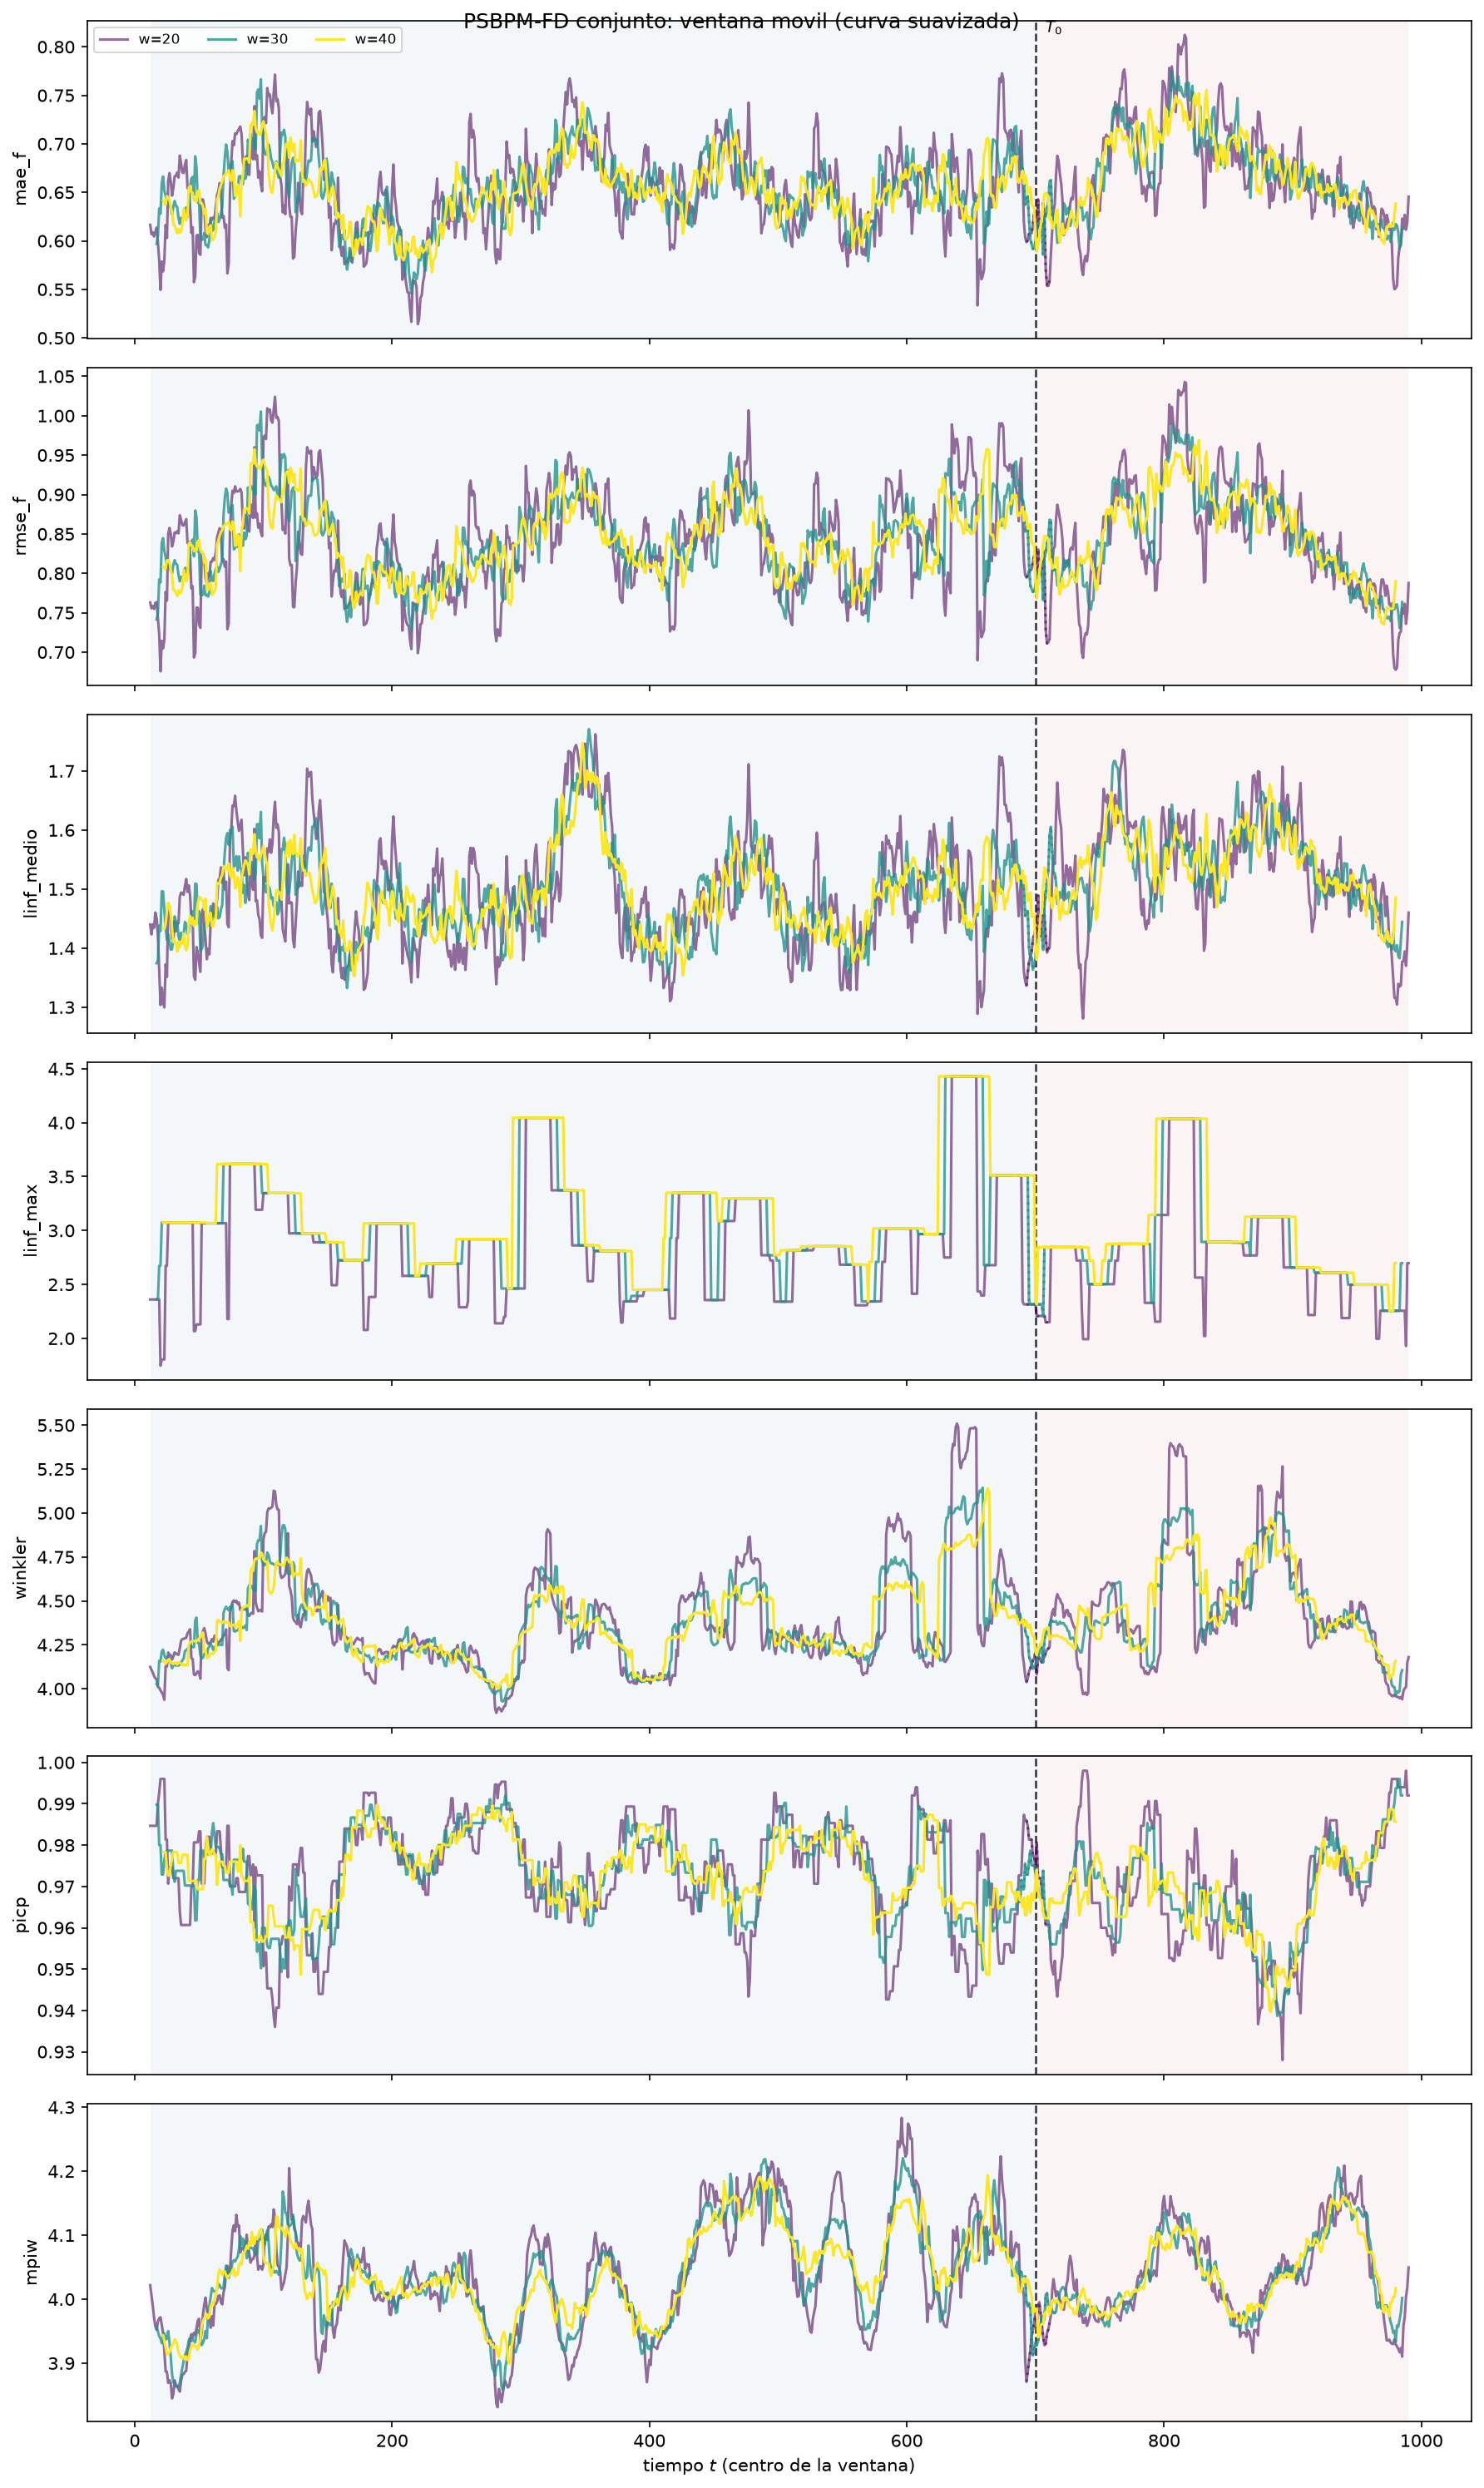

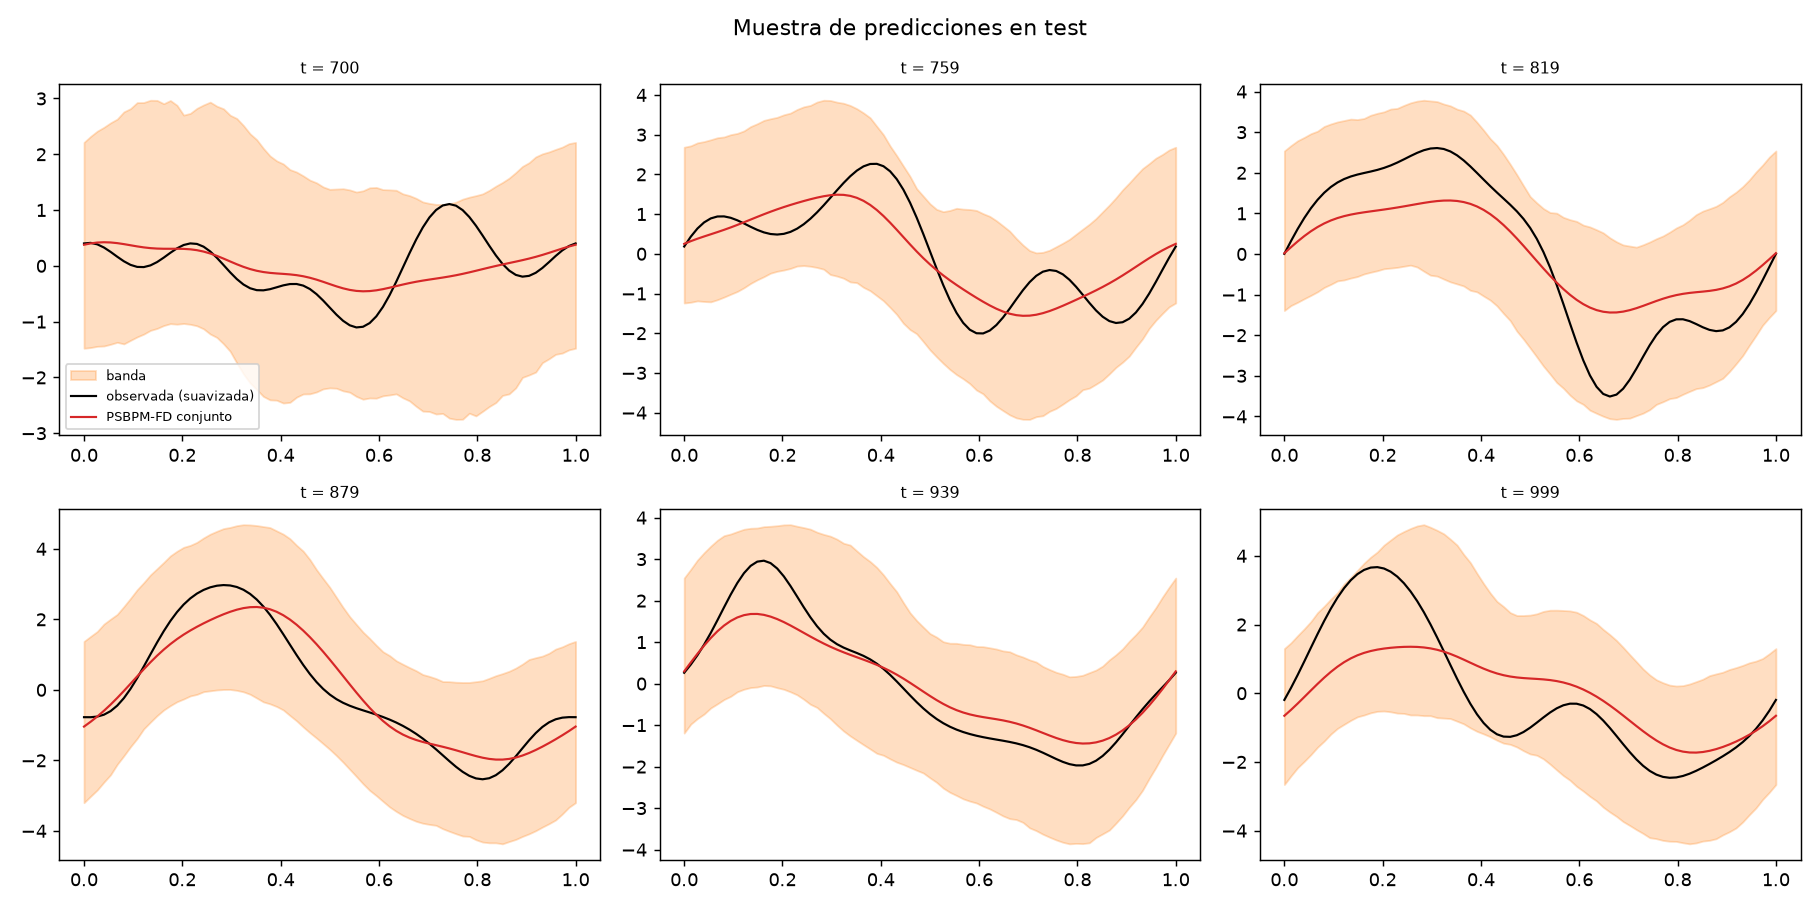

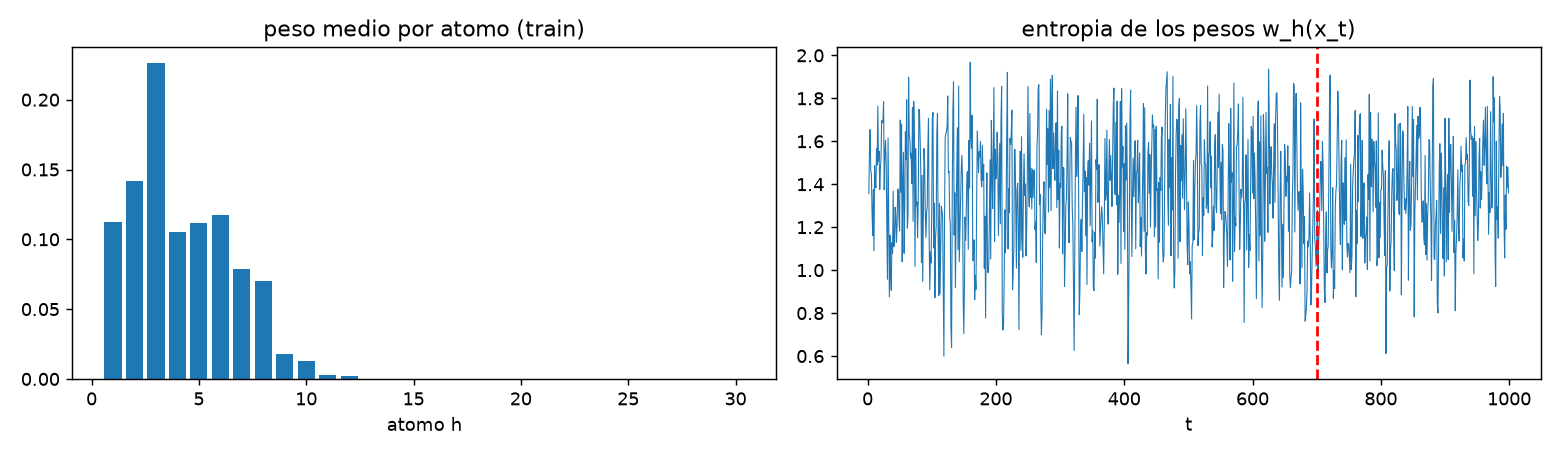

In [4]:
for f in ("55_ventana_movil.png", "57_muestra_predicciones.png", "58_ocupacion_mezcla.png"):
    display(Image(filename=str(paths["out_report"] / f)))